# ¡Hola José!

Mi nombre es Israel, estaré ayudándote a revisar este proyecto para que quede en su mejor versión.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. Esto es útil para que te acostumbres a un escenario laboral. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres**.

¿Cómo funciona esta revisión? Leeré atentamente tu código y te señalaré tus fortalezas y aquellas cosas que podemos mejorar. Los comentarios aparecerán de esta forma:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si todo está perfecto y no se requieren cambios en el código.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta. Se aceptan uno o dos comentarios de este tipo en el borrador, pero si hay más, deberás hacer las correcciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si definitivamente hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma si algo no queda claro (copia este código en una celda markdown):

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola, muchas gracias por tus comentarios y la revisión.        
</div>

**Es un gusto acompañarte en este proceso, ¡empecemos!**

<div class="alert alert-block alert-success">
<b>Review General. (Iteración 1)</b> <a class="tocSkip"></a>
    
Buenas José, quería tomarme este momento al inicio de tu proyecto para
comentarte mis apreciaciones generales sobre esta iteración de tu entrega.

Antes que nada, quería darte la bienvenida al mundo de los datos. Te deseo lo mejor y espero que
consigas lograr tus objetivos. Personalmente, me gustaría brindarte el siguiente consejo, está bien
equivocarse, es normal y es una de las mejores formas de aprender. Aprendemos de los errores y
mejorarás en programación a medida que descubras nuevas herramientas, soluciones y formas de
pensar. Esa experiencia es la que te ayudará a convertirte en un gran Data Analyst.

Ahora sí, yendo a esta notebook, quiero felicitarte porque tus resoluciones cumplen con gran parte
de lo solicitado. Esto demuestra que tienes un buen manejo tanto de Python como de la lógica
necesaria para resolver los ejercicios. Solo encontré algunos detalles puntuales que deberíamos
ajustar para reforzar el objetivo de aprendizaje del proyecto.

Espero con ansias la resolución de estos pequeños detalles para poder avanzar con la aprobación del
proyecto. Nuevamente, ¡bien hecho!

Saludos.
</div>


# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [28]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr

### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Excelente trabajo. La carga y exploración inicial cumplen con lo solicitado: se importan las librerías, se carga correctamente el conjunto de datos, se revisan los tipos y valores nulos y se muestran las primeras filas.

</div>

## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
- La columna `edad` viene como tipo float, se recomienda cambiar a número entero para mejor legibilidad.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad` 
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_plublicidad_dirigida`
- `satisfacción`
- `ingreso_anual`
  
La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` tiene un tipo de dato float.64 el cuál sería mejor cambiar a edad entera para mejorar legibilidad y cálculos.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Corregir el tipo de dato
df['edad']= df['edad'].astype('int')

In [5]:
# verificar cambios
df['edad'].head()

0    44
1    36
2    46
3    56
4    35
Name: edad, dtype: int64

#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**:

Diagnóstico inicial de variables numéricas

- `edad` El promedio de las clientes analizados es 38 años.
- `nivel_ingreso` En promedio el ingreso de los clientes es: 30,000.00
- `visitas_mes` En promedio un cliente visita el sitio 10 veces por mes.
- `compras_mes` Los clientes hacen al menos 1 compra el mes en promedio.
- `gasto_plublicidad_dirigida` El máximo gasto realizado a un cliente fue 75.51.
- `satisfacción` Se tiene una calificación promedio de satifacción de 3.6.
- `miebros_premium` Se tiene un bajo número de clientes premium.
- `abandono` La tasa de abandono en promedio es de 15%.
- `ingreso_anual` El ingreso promedio anual es de 36.59.

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
cols =['miembro_premium','abandono']
for col in cols:
    print(df[col].value_counts())


0    12911
1     2089
Name: miembro_premium, dtype: int64
0    12739
1     2261
Name: abandono, dtype: int64


✍️ **Comentario**: 
Diagnóstico inicial de variables binarias

- `miembro_premium` — Se puede observar que la mayor parte de los usuarios no son miembros premium.
- `abandono` — La cantidad de usuarios que abandona es del 15%.

#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
df[['id_cliente','tipo_dispositivo', 'region']].nunique()

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64

In [9]:
# Explorar variables categóricas y cómo se distribuyen
df[['tipo_dispositivo', 'region']].value_counts(normalize=True)

tipo_dispositivo  region
móvil             norte     0.189533
                  oeste     0.165933
                  sur       0.165533
                  este      0.133533
escritorio        norte     0.075000
                  oeste     0.062333
                  sur       0.059600
                  este      0.051067
tablet            norte     0.028467
                  oeste     0.025733
                  sur       0.023267
                  este      0.020000
dtype: float64

✍️ **Comentario**: 
Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Tenemos 3 categorías diferentes, siendo movil la más popular con 9,818 apariciones.
- `region` - Tenemos 4 categorías donde norte es la más popular con 4,395 apariciones.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Revisa esta sección. La conversión de `edad` es correcta, pero la exploración debe alinearse con la solución. Para las variables numéricas, evita interpretar normalidad, outliers o estabilidad únicamente con `describe()` sin aplicar un criterio específico. Para las binarias, `df[['miembro_premium', 'abandono']].value_counts()` muestra combinaciones entre ambas columnas, no la distribución individual de cada variable; reporta los conteos o proporciones de cada una por separado. La afirmación de que ser premium reduce el abandono no puede concluirse con ese resultado. En las categóricas, utiliza `value_counts(normalize=True)` para `tipo_dispositivo` y `region`; `describe()` e incluir `id_cliente` en la distribución no permite evaluar correctamente sus proporciones.

</div>

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola Israel, muchas gracias por tus comentarios y por la buena vibra que me dejas, creo que ya atendí todos los comentarios de esta sección :)        
</div>

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

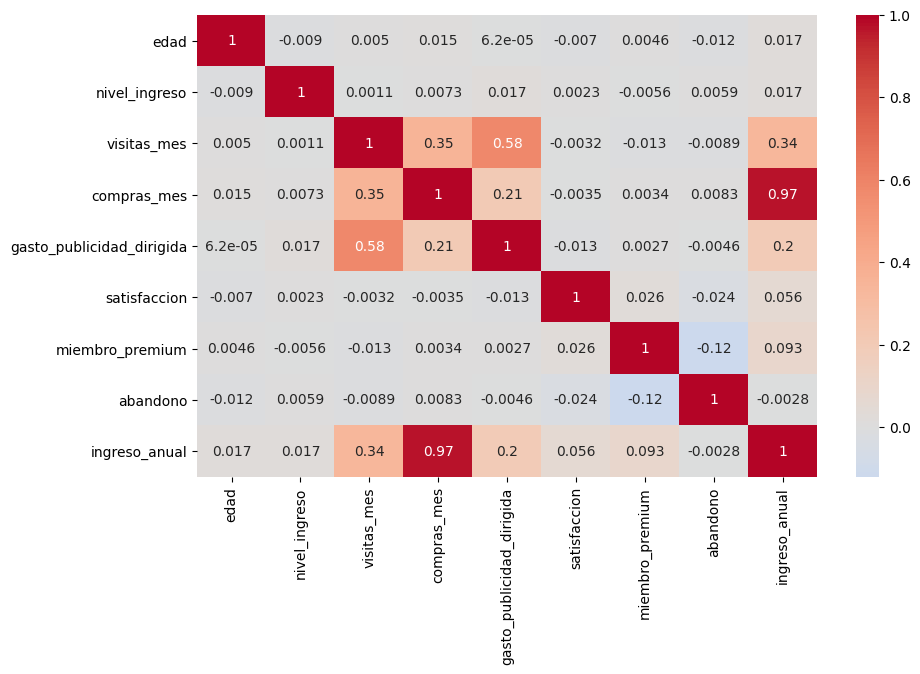

In [20]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

✍️ **Comentario**:

Observaciones generales (Heatmap)  
- Se observa `visitas_mes` y `gasto_publicidad_dirigida` con una correlación que vale la pena analizar más a detalle. Así como `visitas_mes` e `ingreso_anual`.

Observaciones respecto a `ingreso_anual`  
- La columa `compras_mes` e `ingreso_anual` tienen una correlación cercana a 1, esto podría indicar una colinealidad que podría analizarse más adelante


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
- Explica por qué.

-En este caso la creación de un scatterplot general no es necesario, ya que solo hay dos pares de claves que se tienen una correlación alta y son las que vale la pena analizar más a detalle.

### Scatterplot para pares clave

<AxesSubplot:xlabel='visitas_mes', ylabel='gasto_publicidad_dirigida'>

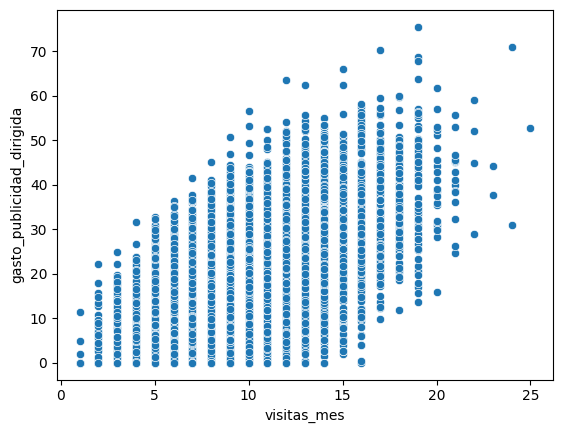

In [11]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df, x= 'visitas_mes', y= 'gasto_publicidad_dirigida')

<AxesSubplot:xlabel='visitas_mes', ylabel='ingreso_anual'>

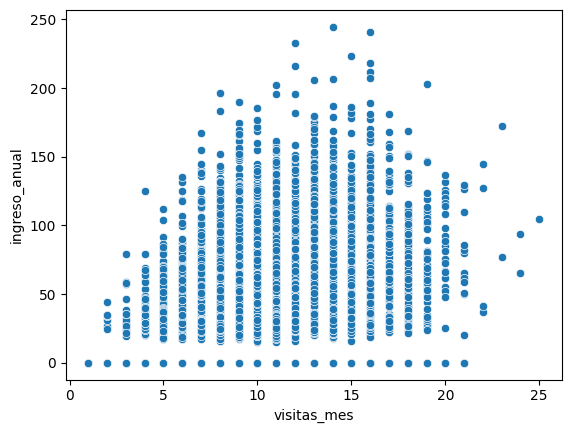

In [21]:
sns.scatterplot(data=df, x= 'visitas_mes', y= 'ingreso_anual')

✍️ **Observaciones iniciales (Scatterplot)**: 

**visitas_mes vs gasto_publicidad_dirigida**
- Se observa una correlación con dirección positiva
- Se observa una dispersión baja
- Se obeservan poco valores como outliers.

**compras_mes vs ingreso_anual**
- Se observa una correlación con dirección positiva
- Hay una dispersión baja en los datos
- Se observa una posible colinealidad entre estas dos variables.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Revisa esta sección. En el heatmap, `plt.figure(figsize=(10,6))` debe ejecutarse antes de `sns.heatmap`; en el orden actual se crea una figura vacía después del gráfico. El análisis identifica correctamente `compras_mes` vs `ingreso_anual`, pero sustituye el segundo par requerido por `visitas_mes` vs `gasto_publicidad_dirigida`. Debes visualizar `visitas_mes` vs `ingreso_anual`, cuya relación es positiva moderada y presenta alta dispersión. El análisis de publicidad puede conservarse solo como complemento.

</div>



<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Atendidos todos los comentarios de esta sección.       
</div>



## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [26]:
# Calcular correlación entre variables relevantes
pearson_1 = df['ingreso_anual'].corr(df['compras_mes'], method='pearson')
print( f'El coeficiente de Pearson para las columnas "visitas_mes" y "gasto_publicidad_dirigida" es:{pearson_1:.4f}')
spearman_1= df['ingreso_anual'].corr(df['compras_mes'], method='spearman')
print( f'El coeficiente de Spearman para las columnas "visitas_mes" y "gasto_publicidad_dirigida" es:{spearman_1:.4f}')

El coeficiente de Pearson para las columnas "visitas_mes" y "gasto_publicidad_dirigida" es:0.9671
El coeficiente de Spearman para las columnas "visitas_mes" y "gasto_publicidad_dirigida" es:0.9675


In [27]:
# Calcular correlación entre variables relevantes
pearson_1 = df['ingreso_anual'].corr(df['visitas_mes'], method='pearson')
print( f'El coeficiente de Pearson para las columnas "compras_mes" y "ingreso_anual" es:{pearson_1:.4f}')
spearman_1= df['ingreso_anual'].corr(df['visitas_mes'], method='spearman')
print( f'El coeficiente de Spearman para las columnas "compras_mes" y "ingreso_anual" es:{spearman_1:.4f}')

El coeficiente de Pearson para las columnas "compras_mes" y "ingreso_anual" es:0.3371
El coeficiente de Spearman para las columnas "compras_mes" y "ingreso_anual" es:0.3210


✍️ **Comentario**: 
Observaciones de correlación

**`ingreso_anual` vs `compras_mes`**
- La correlación por ambos métodos da como resultado 0.96 lo cuál confirma la colinealidad del par de variables.
- Probablemente una variable dependa de la otra para su desarrollo.

**`ingreso_anual` vs `visitas_mes`**
- La correlación entre estas dos variables es moderada-debil.
- Ambos métodos arrojan aproximádamente el mismo resultado, por lo que usar el método de Pearson puede ser aceptado.

### Punto-biserial

In [30]:
# Calcular correlación entre variables relevantes
punto_biserial_1 = pointbiserialr(df['ingreso_anual'], df['miembro_premium'])
punto_biserial_1

SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

In [31]:
punto_biserial_2 = pointbiserialr(df['ingreso_anual'], df['abandono'])
punto_biserial_2

SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)

✍️ **Comentario**:
Observaciones Punto-biserial

**`ingreso_anual` vs `miembro_premium`**
- La correlación mostrada entre las columnas "ingreso_anual" y "miembro_premium", no muestra una correlación significante.

**`ingreso_anual` vs `abandono`**
- La correlación mostrada entre las columnas "ingreso_anual" y "abandono", no muestra una correlación significante.

### V de Cramér

In [41]:
# Función para calcular V de Cramér
def v_cramer(df, col1 , lista1):
    for col in lista1:
        tabla = pd.crosstab(df[col1],df[col])
        chi2, p_value, dof, expected = chi2_contingency(tabla)
        n= tabla.values.sum()
        v= np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
        print(f'V de Cramér para:{col}: {v}')


In [42]:
# Aplicar V de Cramér en variables relevantes

v_cramer(df, 'abandono', ['tipo_dispositivo','region','miembro_premium'])

V de Cramér para:tipo_dispositivo: 0.007245190431994803
V de Cramér para:region: 0.015429712175030079
V de Cramér para:miembro_premium: 0.12021874609740511


✍️ **Comentario**:

En las columnas 'abandono' y 'miembro_premium' el factor de correlación de Cramér es moderado, vale la pena indagar más al respecto.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Revisa esta sección. Pearson y Spearman deben calcularse para `ingreso_anual` vs `compras_mes` y para `ingreso_anual` vs `visitas_mes`; el segundo par esperado tiene Pearson ≈ 0.337 y Spearman ≈ 0.321. Actualmente se utiliza publicidad vs visitas y faltan diagnósticos específicos de dirección y magnitud. En punto-biserial, los cruces requeridos son `ingreso_anual` vs `miembro_premium` y `ingreso_anual` vs `abandono`; actualmente se utilizan `edad` y `nivel_ingreso`, por lo que los resultados no corresponden a lo esperado. En V de Cramér deben evaluarse `abandono` vs `tipo_dispositivo`, `abandono` vs `region` y `abandono` vs `miembro_premium`, no solamente `region` vs `tipo_dispositivo`. Incluye también las importaciones estadísticas al inicio del notebook y reemplaza los textos genéricos `var1` y `var2` por interpretaciones de los pares reales.

</div>


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Atendidos todos los comentarios de esta sección.       
</div>

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 —  ANÁLISIS PARA LAS COLUMNAS `visitas_mes` e `ingreso_anual`

**Evidencia visual:** 
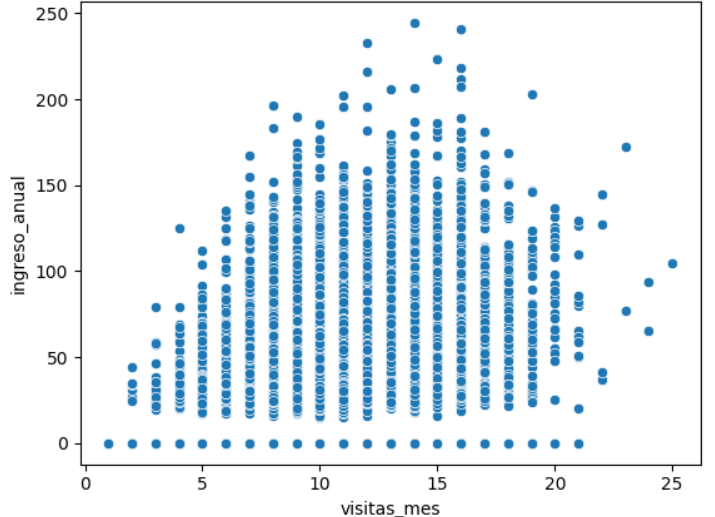

**Evidencia numérica:** 
El coeficiente de Pearson es:0.3371 ≈ 0.3210 Coeficiente de Spearman

**Interpretación**  
Los usuarios que visitan más veces la página presentan un ingreso anual mayor, este resultado tiene una grado moderado pero significativo de correlación.

**No podemos afirmar**  
Que los usuarios con un ingreso anual alto visitará más visitará el sitio.

**Implicación de negocio**  
Enfocar estrategias de retención del usuario en la página para captar más ventas.

### Hallazgo 2 — ANÁLISIS PARA LAS COLUMNAS `compras_mes` e `ingreso_anual`

**Evidencia visual:**   
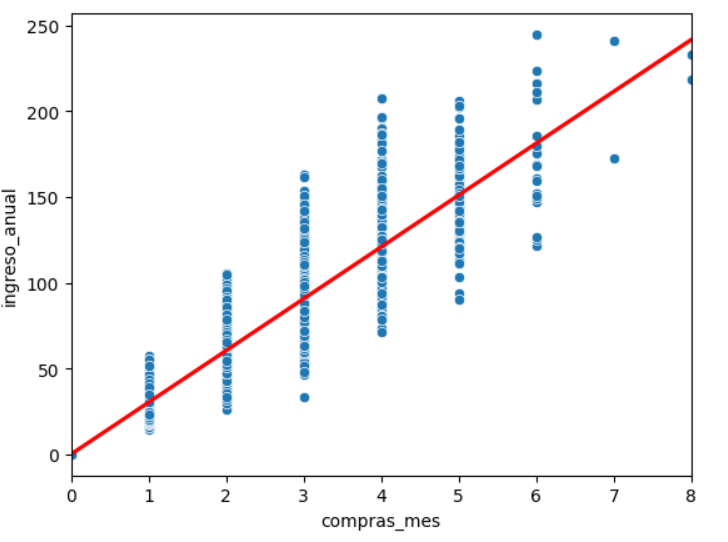

**Evidencia numérica:** 

El coeficiente de Pearson es:0.967 ≈ 0.967 Coeficiente de Spearman

**Interpretación**  
Como podemos ver en el scatterplot y en los coeficientes de correlación de Pearson y Spearman, estas dos columnas tienen una colinealidad definida y visible no causal.

**No podemos afirmar**  
Que las compras mesuales de los usuarios dependan del ingreso anual de los mismos.

**Implicación de negocio**  
Analizar más a fondo como se comporta el ingreso de los usuarios con el monto de las compas.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Revisa esta sección. El hallazgo sobre `compras_mes` vs `ingreso_anual` es correcto, pero debe presentar claramente Pearson y Spearman ≈ 0.967, interpretación no causal, límite e implicación de negocio. El otro hallazgo principal requerido es `visitas_mes` vs `ingreso_anual`, con Pearson ≈ 0.337 y Spearman ≈ 0.321; actualmente fue sustituido por publicidad vs visitas. Este último análisis puede quedar únicamente como complemento.

</div>

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Atendidos todos los comentarios de esta sección. Espero haber entendido los errores que me marcaste Israel y con esto poder conclluir de manera satisfactoria el proyecto. Gracias y saludos.     

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- Tener el dato del gasto por compra o compras total podría dar un mejor panorama de como está capitalizando la publicidad.

### **Próximos pasos** 

Probar segmentación adicional
- Analizar las edades de los usarios relativos a las compras
- Obtener el monto por compra y fechas de compra.
